# Steam Game Data Analysis

**Dataset:** `steam_games_data.csv` — 29,950 games scraped from the Steam API  
**Columns:** AppID, Name, Price_USD, Genres, Total_Reviews, Positive_Reviews, Rating_Percent, Initial_Price_THB, Windows, Mac, Linux

---

---
## Step 1 — Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn scipy -q


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, pointbiserialr, f_oneway

# ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Step 2 — Load & Inspect the Data

In [3]:
df = pd.read_csv('steam_games_data.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('Column types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())

Dataset shape: 29,950 rows × 11 columns

Column types:
AppID                  int64
Name                     str
Price_THB            float64
Genres                   str
Total_Reviews            str
Positive_Reviews         str
Rating_Percent           str
Initial_Price_THB        str
Windows                  str
Mac                      str
Linux                    str
dtype: object

Missing values per column:
AppID                 0
Name                  7
Price_THB             0
Genres               63
Total_Reviews         0
Positive_Reviews      0
Rating_Percent        0
Initial_Price_THB     6
Windows               0
Mac                   0
Linux                 0
dtype: int64


In [4]:
df.head(10)

,AppID,Name,Price_THB,Genres,Total_Reviews,Positive_Reviews,Rating_Percent,Initial_Price_THB,Windows,Mac,Linux
0,10,Counter-Strike,189.0,Action,167175,162128,96.98,189.0,True,True,True
1,20,Team Fortress Classic,115.0,Action,6873,5943,86.47,115.0,True,True,True
2,30,Day of Defeat,115.0,Action,4416,3892,88.13,115.0,True,True,True
3,40,Deathmatch Classic,115.0,Action,2402,1976,82.26,115.0,True,True,True
4,50,Half-Life: Opposing Force,115.0,Action,24342,23246,95.5,115.0,True,True,True
5,60,Ricochet,115.0,Action,4492,3688,82.1,115.0,True,True,True
6,70,Half-Life,189.0,Action,113408,109576,96.62,189.0,True,True,True
7,80,Counter-Strike: Condition Zero,189.0,Action,20917,18990,90.79,189.0,True,True,True
8,130,Half-Life: Blue Shift,115.0,Action,17874,16567,92.69,115.0,True,True,True
9,220,Half-Life 2,220.0,Action,195922,191414,97.7,220.0,True,False,True


---
## Step 3 — Clean the Data

In [6]:
df['Total_Reviews']    = pd.to_numeric(df['Total_Reviews'].astype(str).str.replace(',', ''), errors='coerce')
df['Positive_Reviews'] = pd.to_numeric(df['Positive_Reviews'].astype(str).str.replace(',', ''), errors='coerce')
df['Rating_Percent']   = pd.to_numeric(df['Rating_Percent'], errors='coerce')
df['Price_THB']        = pd.to_numeric(df['Price_THB'], errors='coerce')

df_clean = df.dropna(subset=['Rating_Percent']).drop_duplicates().copy()

# Convert platform columns to bool
for platform in ['Windows', 'Mac', 'Linux']:
    df_clean[platform] = df_clean[platform].astype(str).str.lower().map({'true': True, 'false': False}).fillna(False)

print(f'Rows before cleaning : {len(df):,}')
print(f'Rows after cleaning  : {len(df_clean):,}')
print(f'Rows removed         : {len(df) - len(df_clean):,}')

Rows before cleaning : 29,950
Rows after cleaning  : 29,885
Rows removed         : 65


---
## Step 4 — Basic Statistics & Distribution

In [8]:
summary_cols = ['Rating_Percent', 'Total_Reviews', 'Price_THB']
df_clean[summary_cols].describe().round(2)

,Rating_Percent,Total_Reviews,Price_THB
count,29885.00,29885.00,29885.00
mean,62.98,2354.21,158.70
std,32.16,38554.36,404.36
min,0.00,0.00,0.00
25%,50.00,5.00,23.00
50%,73.11,27.00,115.00
75%,87.80,183.00,219.00
max,100.00,5017291.00,50000.00


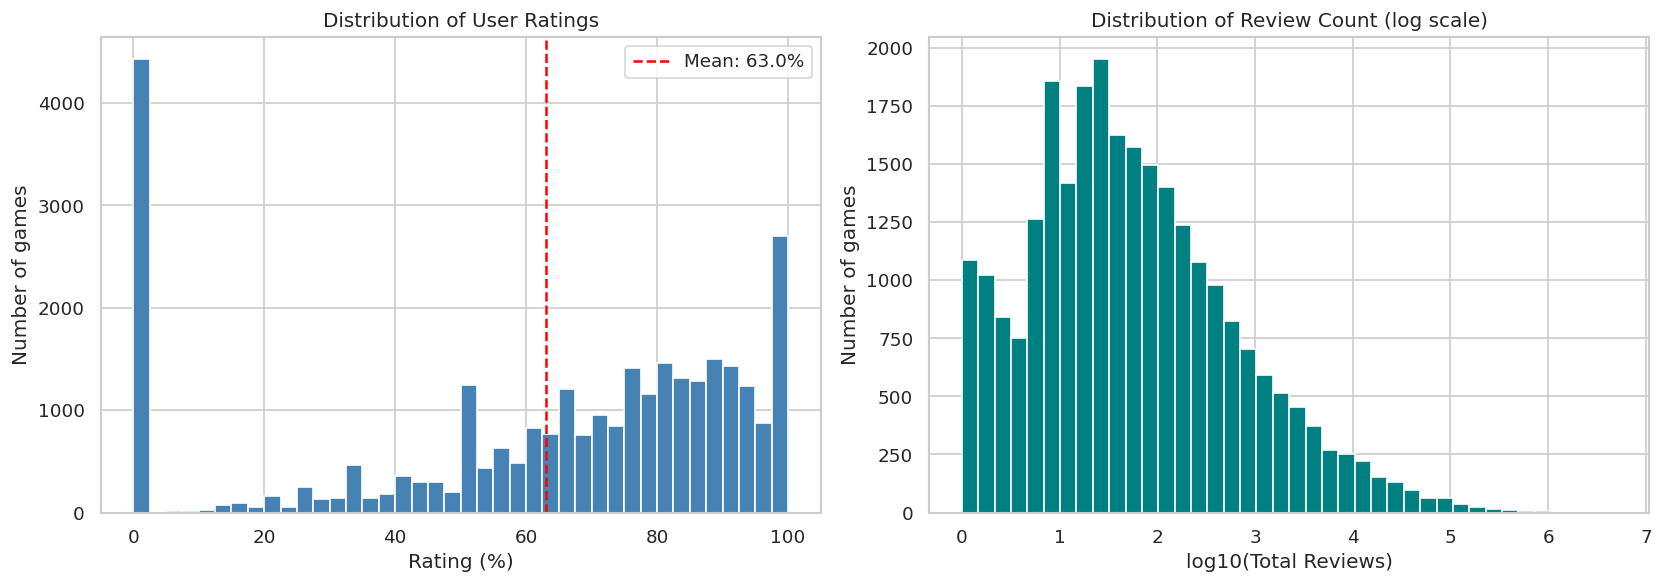

Most games have very few reviews — the distribution is heavily right-skewed.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['Rating_Percent'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of User Ratings')
axes[0].set_xlabel('Rating (%)')
axes[0].set_ylabel('Number of games')
axes[0].axvline(df_clean['Rating_Percent'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_clean['Rating_Percent'].mean():.1f}%")
axes[0].legend()

reviews_nonzero = df_clean[df_clean['Total_Reviews'] > 0]['Total_Reviews']
axes[1].hist(np.log10(reviews_nonzero), bins=40, color='teal', edgecolor='white')
axes[1].set_title('Distribution of Review Count (log scale)')
axes[1].set_xlabel('log10(Total Reviews)')
axes[1].set_ylabel('Number of games')

plt.tight_layout()
plt.show()
print('Most games have very few reviews — the distribution is heavily right-skewed.')

---
## Step 5 — Factor 1: Price vs. Rating (with Correlation Tests)
**Question:** Do more expensive games get better user ratings?

We use three statistical tests:
- **Pearson r** — linear correlation between price and rating
- **One-way ANOVA** — tests whether mean ratings differ significantly across price tiers (F-stat + p-value)
- **Eta-squared (η²)** — effect size: how much of the variance in rating is explained by price tier

In [12]:
# Price tiers
bins   = [-1, 0, 100, 200, 500, 60000]
labels = ['Free (0)', 'Low (1–100)', 'Mid (101–200)', 'High (201–500)', 'Premium (500+)']
df_clean['Price_Tier'] = pd.cut(df_clean['Price_THB'], bins=bins, labels=labels)

price_stats = (
    df_clean
    .groupby('Price_Tier', observed=True)['Rating_Percent']
    .agg(['mean', 'median', 'count'])
    .round(2)
    .rename(columns={'mean': 'Avg Rating', 'median': 'Median Rating', 'count': 'Game Count'})
)
print(price_stats)

# ── Correlation tests ──────────────────────────────────────────
valid_price = df_clean.dropna(subset=['Price_THB', 'Rating_Percent'])

# Pearson r (linear correlation)
r_price, p_pearson = pearsonr(valid_price['Price_THB'], valid_price['Rating_Percent'])

# One-way ANOVA across price tiers
groups = [group['Rating_Percent'].dropna().values
          for _, group in df_clean.groupby('Price_Tier', observed=True)]
F_stat, p_anova = f_oneway(*groups)

# Eta-squared: SS_between / SS_total
grand_mean = df_clean['Rating_Percent'].mean()
ss_total   = ((df_clean['Rating_Percent'] - grand_mean) ** 2).sum()
tier_means = df_clean.groupby('Price_Tier', observed=True)['Rating_Percent'].transform('mean')
ss_between = ((tier_means - grand_mean) ** 2).sum()
eta_sq     = ss_between / ss_total

print(f"\n── Price Correlation Tests ──")
print(f"Pearson r          = {r_price:.3f}  (p = {p_pearson:.4f})")
print(f"ANOVA F-statistic  = {F_stat:.2f}  (p = {p_anova:.2e})")
print(f"Eta-squared (η²)   = {eta_sq:.3f}  → Price tier explains {eta_sq*100:.1f}% of rating variance")

                Avg Rating  Median Rating  Game Count
Price_Tier                                           
Free (0)             28.67           0.00        4676
Low (1–100)          65.13          71.43       10064
Mid (101–200)        68.99          75.05        6587
High (201–500)       74.20          80.00        7576
Premium (500+)       77.37          82.10         982

── Price Correlation Tests ──
Pearson r          = 0.119  (p = 0.0000)
ANOVA F-statistic  = 2165.55  (p = 0.00e+00)
Eta-squared (η²)   = 0.225  → Price tier explains 22.5% of rating variance


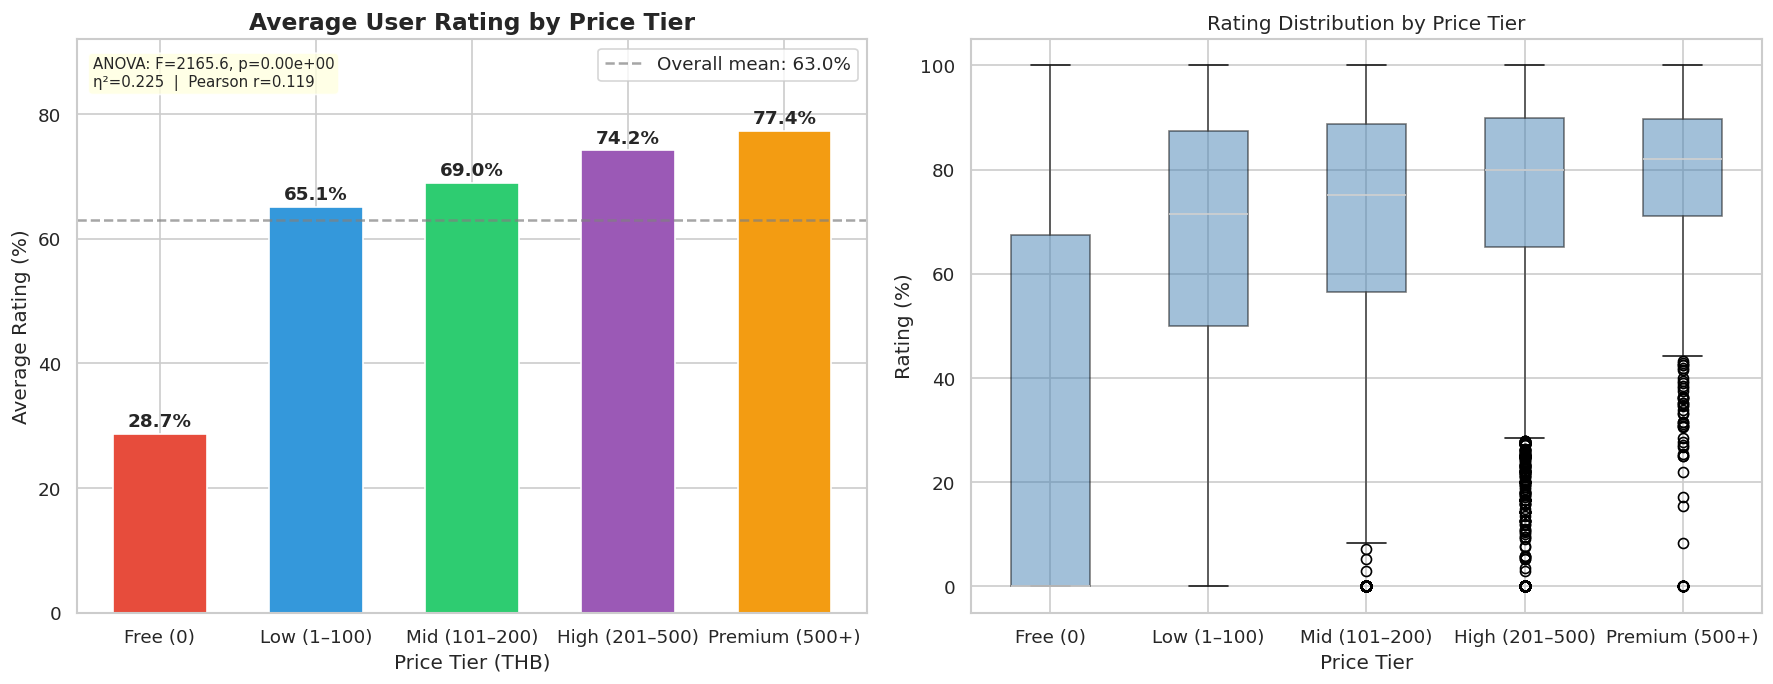

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Bar chart
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']
bars = axes[0].bar(price_stats.index, price_stats['Avg Rating'],
                   color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, price_stats['Avg Rating']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Average User Rating by Price Tier', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price Tier (THB)')
axes[0].set_ylabel('Average Rating (%)')
axes[0].set_ylim(0, 92)
axes[0].axhline(df_clean['Rating_Percent'].mean(), color='gray', linestyle='--', alpha=0.7,
                label=f"Overall mean: {df_clean['Rating_Percent'].mean():.1f}%")
axes[0].legend()
axes[0].text(0.02, 0.97,
             f"ANOVA: F={F_stat:.1f}, p={p_anova:.2e}\nη²={eta_sq:.3f}  |  Pearson r={r_price:.3f}",
             transform=axes[0].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Right: Box plot (shows spread, not just mean)
df_clean.boxplot(column='Rating_Percent', by='Price_Tier', ax=axes[1],
                 notch=False, patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('Rating Distribution by Price Tier')
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('Rating (%)')
plt.suptitle('')

plt.tight_layout()
plt.show()

---
## Step 6 — Factor 2: Genre vs. Rating (with Correlation Tests)
**Question:** Does game genre affect ratings?

Since genre is binary (a game either belongs to a genre or not), we use:
- **Point-biserial r** — correlation between a binary variable and a continuous one
- **Cohen's d** — standardised effect size: how many standard deviations apart are the mean ratings of genre vs. non-genre games?

In [14]:
genres_to_check = ['Indie', 'Action', 'RPG', 'Strategy', 'Casual', 'Adventure', 'Simulation', 'Sports']

for genre in genres_to_check:
    df_clean[f'is_{genre}'] = df_clean['Genres'].str.contains(genre, na=False).astype(int)

genre_stats = []
for genre in genres_to_check:
    subset_in  = df_clean[df_clean[f'is_{genre}'] == 1]['Rating_Percent'].dropna()
    subset_out = df_clean[df_clean[f'is_{genre}'] == 0]['Rating_Percent'].dropna()

    pb_r, pb_p = pointbiserialr(df_clean[f'is_{genre}'], df_clean['Rating_Percent'])

    # Cohen's d
    pooled_std = np.sqrt((subset_in.std()**2 + subset_out.std()**2) / 2)
    cohens_d   = (subset_in.mean() - subset_out.mean()) / pooled_std if pooled_std > 0 else 0

    genre_stats.append({
        'Genre'        : genre,
        'Game Count'   : len(subset_in),
        'Avg Rating'   : round(subset_in.mean(), 2),
        'Avg Reviews'  : round(subset_in.mean(), 0),
        'Pb-r'         : round(pb_r, 3),
        'p-value'      : round(pb_p, 4),
        "Cohen's d"    : round(cohens_d, 3),
        'Significant'  : '✓' if pb_p < 0.05 else '✗'
    })

genre_df = pd.DataFrame(genre_stats).sort_values('Game Count', ascending=False)
print(genre_df[['Genre','Game Count','Avg Rating','Pb-r','p-value',"Cohen's d",'Significant']].to_string(index=False))

     Genre  Game Count  Avg Rating   Pb-r  p-value  Cohen's d Significant
     Indie       21941       62.87 -0.006   0.3335     -0.013           ✗
    Action       13681       62.11 -0.025   0.0000     -0.050           ✓
 Adventure       11735       63.56  0.015   0.0120      0.030           ✓
    Casual       11240       63.08  0.003   0.6552      0.005           ✗
  Strategy        6141       61.29 -0.027   0.0000     -0.067           ✓
Simulation        5986       58.87 -0.064   0.0000     -0.162           ✓
       RPG        5202       61.28 -0.024   0.0000     -0.064           ✓
    Sports        1440       58.22 -0.033   0.0000     -0.154           ✓


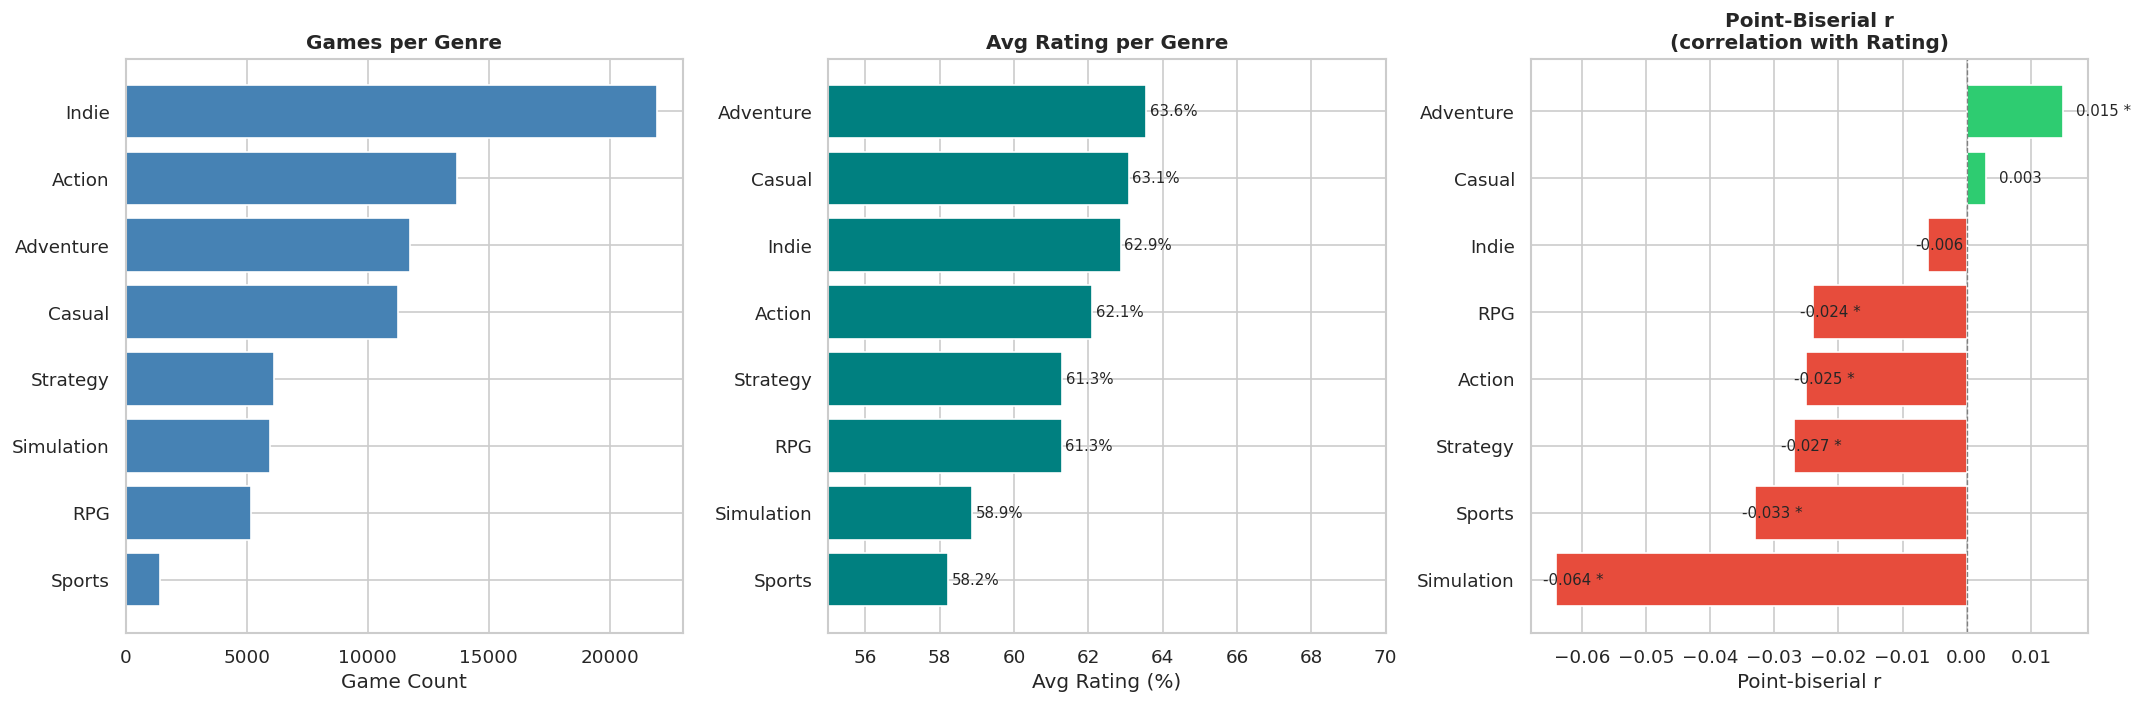

* = statistically significant (p < 0.05)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Count
gs_count = genre_df.sort_values('Game Count', ascending=True)
axes[0].barh(gs_count['Genre'], gs_count['Game Count'], color='steelblue', edgecolor='white')
axes[0].set_title('Games per Genre', fontweight='bold')
axes[0].set_xlabel('Game Count')

# Avg rating
gs_rating = genre_df.sort_values('Avg Rating', ascending=True)
axes[1].barh(gs_rating['Genre'], gs_rating['Avg Rating'], color='teal', edgecolor='white')
axes[1].set_title('Avg Rating per Genre', fontweight='bold')
axes[1].set_xlabel('Avg Rating (%)')
axes[1].set_xlim(55, 70)
for i, val in enumerate(gs_rating['Avg Rating']):
    axes[1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

# Point-biserial r (correlation)
gs_r = genre_df.sort_values('Pb-r')
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in gs_r['Pb-r']]
axes[2].barh(gs_r['Genre'], gs_r['Pb-r'], color=bar_colors, edgecolor='white')
axes[2].axvline(0, color='gray', linestyle='--', lw=0.8)
axes[2].set_title('Point-Biserial r\n(correlation with Rating)', fontweight='bold')
axes[2].set_xlabel('Point-biserial r')
for i, (_, row) in enumerate(gs_r.iterrows()):
    sig = ' *' if row['p-value'] < 0.05 else ''
    axes[2].text(row['Pb-r'] + (0.002 if row['Pb-r'] >= 0 else -0.002),
                 i, f"{row['Pb-r']:.3f}{sig}", va='center', fontsize=9)

plt.tight_layout()
plt.show()
print('* = statistically significant (p < 0.05)')

---
## Step 7 — Factor 3: Review Count vs. Rating (with Spearman + Partial Correlation)
**Question:** Do games with more reviews get better ratings?

We add **Spearman ρ** (better than Pearson for skewed data) and **partial correlation** (controlling for price, to isolate the review effect).

In [17]:
valid = df_clean.dropna(subset=['Rating_Percent', 'Total_Reviews', 'Price_THB'])
valid = valid[valid['Total_Reviews'] > 0].copy()
valid['log_reviews'] = np.log10(valid['Total_Reviews'])

# Pearson r (linear)
r_pearson, p_pearson = pearsonr(valid['log_reviews'], valid['Rating_Percent'])

# Spearman ρ (rank-based, robust to outliers and non-normality)
r_spearman, p_spearman = spearmanr(valid['Total_Reviews'], valid['Rating_Percent'])

# Partial correlation: reviews → rating, controlling for price
# Use residuals approach
from numpy.linalg import lstsq

def partial_corr(x, y, z):
    """Pearson r between x and y, controlling for z."""
    X = np.column_stack([z, np.ones(len(z))])
    res_x = x - X @ lstsq(X, x, rcond=None)[0]
    res_y = y - X @ lstsq(X, y, rcond=None)[0]
    return pearsonr(res_x, res_y)

r_partial, p_partial = partial_corr(
    valid['log_reviews'].values,
    valid['Rating_Percent'].values,
    valid['Price_THB'].values
)

print("── Review Count Correlation Tests ──")
print(f"Pearson r (log reviews vs rating)      = {r_pearson:.3f}  (p = {p_pearson:.4f})")
print(f"Spearman ρ (raw reviews vs rating)     = {r_spearman:.3f}  (p = {p_spearman:.4f})")
print(f"Partial r  (controlling for price)     = {r_partial:.3f}  (p = {p_partial:.4f})")
print()
print("→ Weak positive correlation: more reviews slightly correlates with higher rating,")
print("  but effect is small and mostly explained by price (paid games get more reviews AND better scores).")

── Review Count Correlation Tests ──
Pearson r (log reviews vs rating)      = 0.284  (p = 0.0000)
Spearman ρ (raw reviews vs rating)     = 0.179  (p = 0.0000)
Partial r  (controlling for price)     = 0.280  (p = 0.0000)

→ Weak positive correlation: more reviews slightly correlates with higher rating,
  but effect is small and mostly explained by price (paid games get more reviews AND better scores).


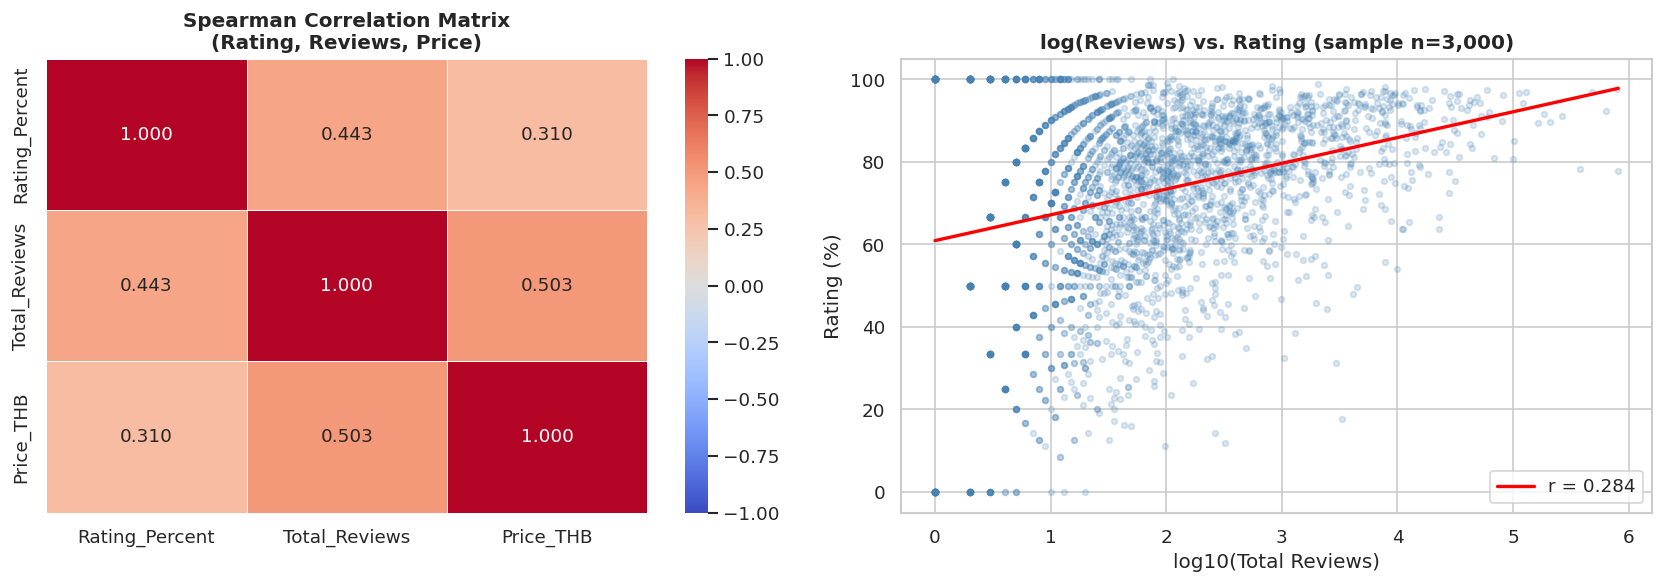

In [19]:
# Correlation matrix — all numeric factors
corr_cols = ['Rating_Percent', 'Total_Reviews', 'Price_THB']
corr_matrix = df_clean[corr_cols].corr(method='spearman').round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Spearman Correlation Matrix\n(Rating, Reviews, Price)', fontweight='bold')

# Scatter
sample = valid.sample(3000, random_state=42)
axes[1].scatter(sample['log_reviews'], sample['Rating_Percent'],
                alpha=0.2, s=12, color='steelblue')
# Add regression line
m, b = np.polyfit(sample['log_reviews'], sample['Rating_Percent'], 1)
x_line = np.linspace(sample['log_reviews'].min(), sample['log_reviews'].max(), 100)
axes[1].plot(x_line, m * x_line + b, color='red', lw=2, label=f'r = {r_pearson:.3f}')
axes[1].set_title('log(Reviews) vs. Rating (sample n=3,000)', fontweight='bold')
axes[1].set_xlabel('log10(Total Reviews)')
axes[1].set_ylabel('Rating (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 8 — Factor 4: Platform Support (with Correlation Tests)
**Question:** Do multi-platform games get better ratings?

We test Mac and Linux support individually with **point-biserial r**, and platform count with **ANOVA**.

In [20]:
df_clean['Platform_Count'] = df_clean[['Windows', 'Mac', 'Linux']].astype(int).sum(axis=1)

platform_stats = (
    df_clean
    .groupby('Platform_Count')['Rating_Percent']
    .agg(['mean', 'count'])
    .round(2)
    .rename(columns={'mean': 'Avg Rating', 'count': 'Game Count'})
)
print('Platform count vs average rating:')
print(platform_stats)

# Point-biserial r per platform
print("\n── Platform Correlation Tests ──")
for plat in ['Mac', 'Linux']:
    pb_r, pb_p = pointbiserialr(
        df_clean[plat].astype(int),
        df_clean['Rating_Percent']
    )
    sig = '(significant)' if pb_p < 0.05 else '(NOT significant)'
    print(f"{plat:6s} support: Pb-r = {pb_r:.3f},  p = {pb_p:.4f}  {sig}")

# ANOVA across platform count groups
groups_plat = [grp['Rating_Percent'].dropna().values
               for _, grp in df_clean.groupby('Platform_Count')]
F_plat, p_plat = f_oneway(*groups_plat)
print(f"\nANOVA (platform count): F = {F_plat:.2f},  p = {p_plat:.4f}")

Platform count vs average rating:
                Avg Rating  Game Count
Platform_Count                        
0                    70.66           6
1                    59.96       20521
2                    67.57        4372
3                    71.37        4986

── Platform Correlation Tests ──
Mac    support: Pb-r = 0.135,  p = 0.0000  (significant)
Linux  support: Pb-r = 0.118,  p = 0.0000  (significant)

ANOVA (platform count): F = 207.51,  p = 0.0000


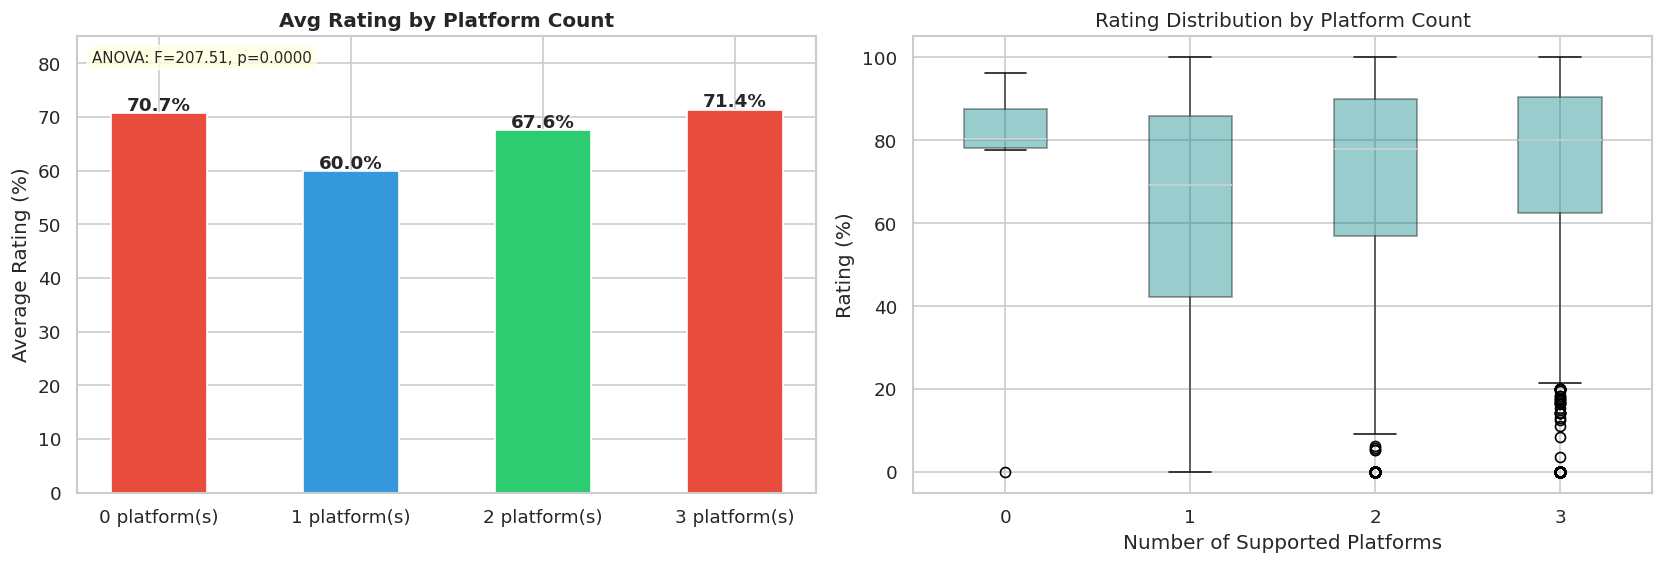

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

platform_labels = [f'{i} platform(s)' for i in platform_stats.index]
bars = axes[0].bar(platform_labels, platform_stats['Avg Rating'],
                   color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white', width=0.5)
for bar, val in zip(bars, platform_stats['Avg Rating']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Avg Rating by Platform Count', fontweight='bold')
axes[0].set_ylabel('Average Rating (%)')
axes[0].set_ylim(0, 85)
axes[0].text(0.02, 0.97, f'ANOVA: F={F_plat:.2f}, p={p_plat:.4f}',
             transform=axes[0].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Box plot by platform count
df_clean.boxplot(column='Rating_Percent', by='Platform_Count', ax=axes[1],
                 patch_artist=True,
                 boxprops=dict(facecolor='teal', alpha=0.4))
axes[1].set_title('Rating Distribution by Platform Count')
axes[1].set_xlabel('Number of Supported Platforms')
axes[1].set_ylabel('Rating (%)')
plt.suptitle('')

plt.tight_layout()
plt.show()

---
## Step 9 — Combined Correlation Heatmap (All Factors)
We now encode all factors numerically and compute a single correlation matrix to compare them head-to-head.

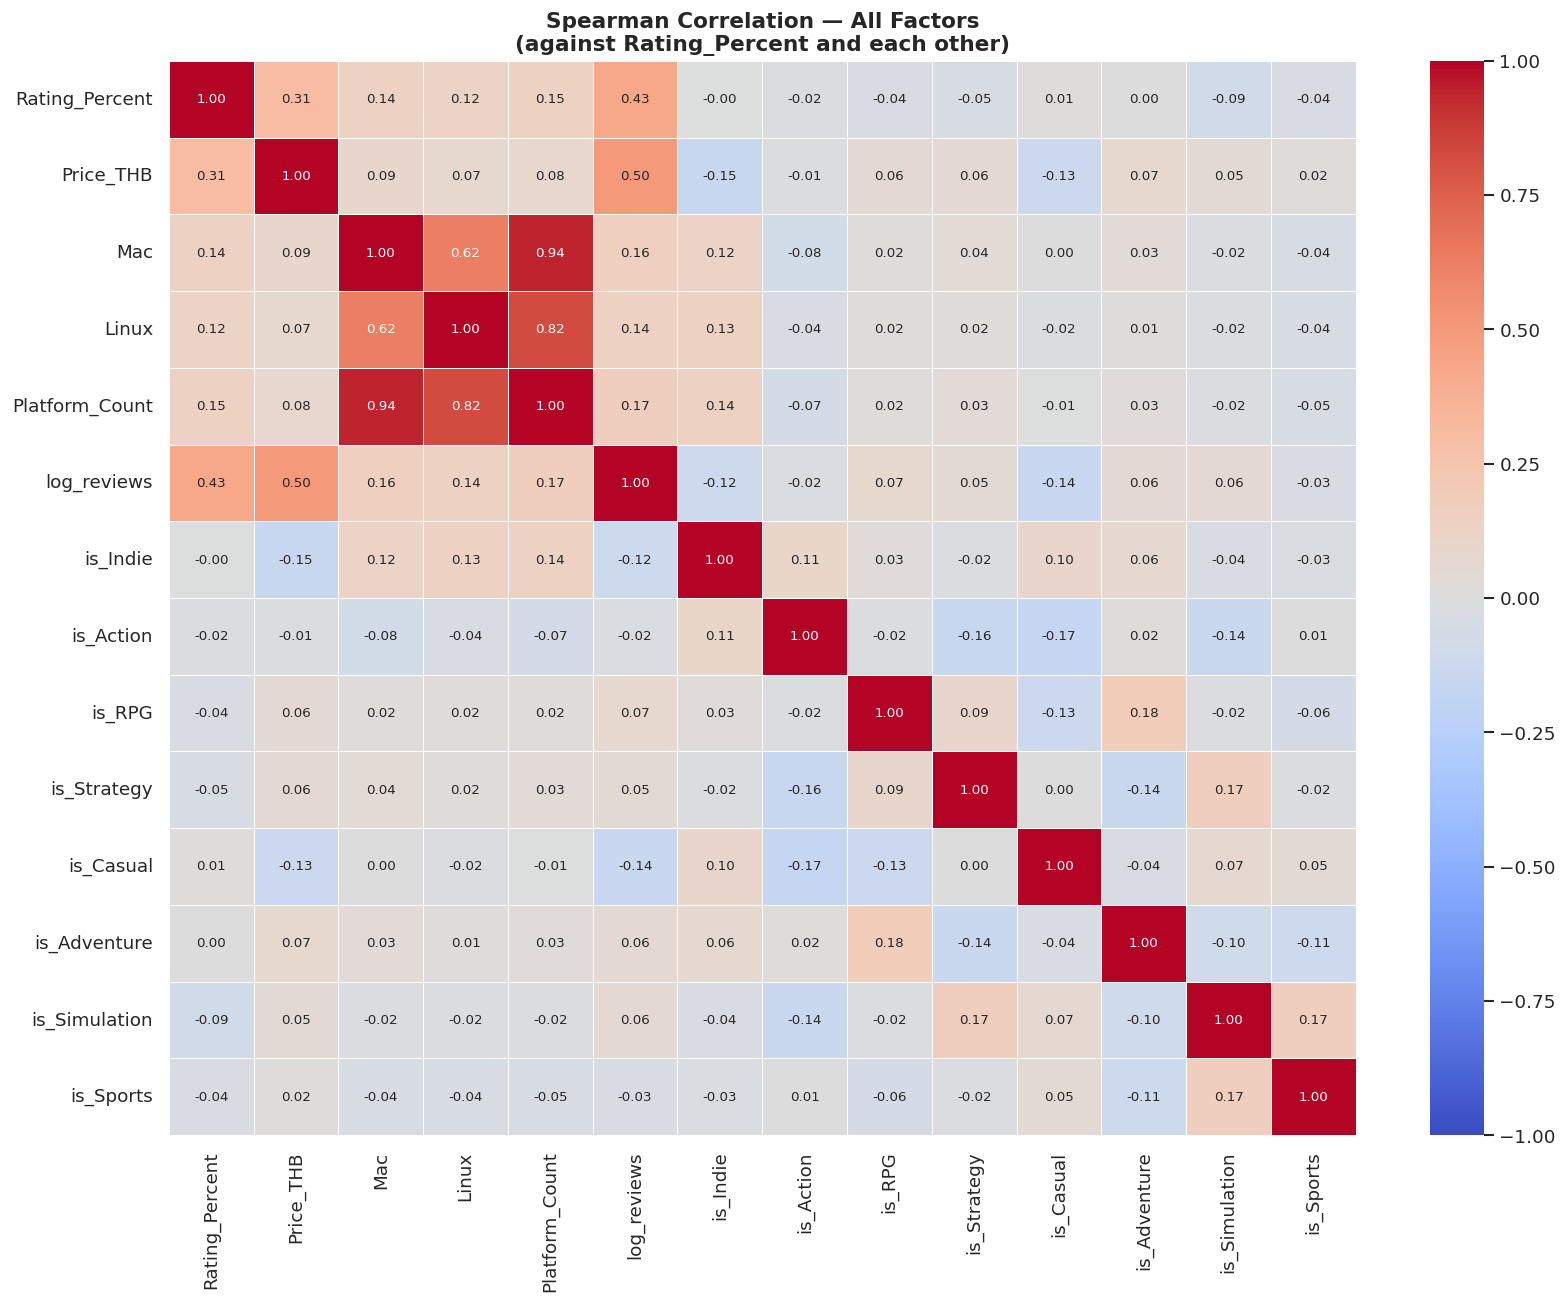

Factors ranked by correlation strength with Rating_Percent:
log_reviews       0.428956
Price_THB         0.310425
Platform_Count    0.145691
Mac               0.137397
Linux             0.119279
is_Simulation     0.088311
is_Strategy       0.046258
is_Sports         0.037747
is_RPG            0.037732
is_Action         0.020170
is_Casual         0.013212
is_Adventure      0.001903
is_Indie          0.001210


In [23]:
# Build a numeric feature table
feature_df = df_clean[['Rating_Percent', 'Price_THB', 'Total_Reviews',
                        'Mac', 'Linux', 'Platform_Count']].copy()
feature_df['log_reviews'] = np.log10(feature_df['Total_Reviews'].clip(lower=1))

for genre in genres_to_check:
    feature_df[f'is_{genre}'] = df_clean[f'is_{genre}']

feature_df['Mac']   = feature_df['Mac'].astype(int)
feature_df['Linux'] = feature_df['Linux'].astype(int)

corr_full = feature_df.drop(columns=['Total_Reviews']).corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr_full, dtype=bool)
# Only show lower triangle
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.4,
            annot_kws={'size': 8})
ax.set_title('Spearman Correlation — All Factors\n(against Rating_Percent and each other)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Print just the row for Rating_Percent, sorted by absolute value
rating_corr = corr_full['Rating_Percent'].drop('Rating_Percent').abs().sort_values(ascending=False)
print("Factors ranked by correlation strength with Rating_Percent:")
print(rating_corr.to_string())

---
## Step 10 — Define Success & Build Feature Matrix

In [24]:
# Define success: rating ≥ 70% AND at least 100 reviews
df_clean['Is_Success'] = (
    (df_clean['Rating_Percent'] >= 70) &
    (df_clean['Total_Reviews'] >= 100)
).astype(int)

total   = len(df_clean)
success = df_clean['Is_Success'].sum()
print(f'Successful games : {success:,} / {total:,}  ({100*success/total:.1f}%)')
print(f'Struggling games : {total-success:,} / {total:,}  ({100*(total-success)/total:.1f}%)')

Successful games : 7,505 / 29,885  (25.1%)
Struggling games : 22,380 / 29,885  (74.9%)


---
## Step 11 — Machine Learning: Random Forest Classifier
**Goal:** Train a model to predict whether a game will be **successful** (rating ≥ 70% + ≥ 100 reviews) based on:
- Price
- Genre flags
- Platform support

We use a **Random Forest** because it:
- Handles non-linear relationships and interactions automatically
- Is robust to outliers and skewed distributions
- Gives us **feature importances** — a direct answer to "which factor matters most?"
- Doesn't need feature scaling

In [26]:
# ── Build Feature Matrix ──────────────────────────────────────
feature_cols = (
    ['Price_THB', 'Mac', 'Linux', 'Platform_Count']
    + [f'is_{g}' for g in genres_to_check]
)

ml_df = df_clean[feature_cols + ['Is_Success']].dropna().copy()
ml_df['Mac']   = ml_df['Mac'].astype(int)
ml_df['Linux'] = ml_df['Linux'].astype(int)

X = ml_df[feature_cols]
y = ml_df['Is_Success']

print(f'Feature matrix shape: {X.shape}')
print(f'Class balance  →  Success: {y.mean()*100:.1f}%   Failure: {(1-y.mean())*100:.1f}%')

# ── Train / Test Split (80 / 20) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {len(X_train):,}   Test size: {len(X_test):,}')

Feature matrix shape: (29885, 12)
Class balance  →  Success: 25.1%   Failure: 74.9%
Train size: 23,908   Test size: 5,977


In [27]:
# ── Train Random Forest ───────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',   # handles class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred   = rf.predict(X_test)
y_prob   = rf.predict_proba(X_test)[:, 1]

acc  = (y_pred == y_test).mean()
roc  = roc_auc_score(y_test, y_prob)

# Cross-validation score (5-fold)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)

print(f"Test Accuracy   : {acc*100:.1f}%")
print(f"ROC-AUC (test)  : {roc:.3f}")
print(f"ROC-AUC (5-fold CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Struggling', 'Successful']))

Test Accuracy   : 73.3%
ROC-AUC (test)  : 0.778
ROC-AUC (5-fold CV): 0.759 ± 0.041

              precision    recall  f1-score   support

  Struggling       0.87      0.76      0.81      4476
  Successful       0.48      0.66      0.55      1501

    accuracy                           0.73      5977
   macro avg       0.67      0.71      0.68      5977
weighted avg       0.77      0.73      0.75      5977



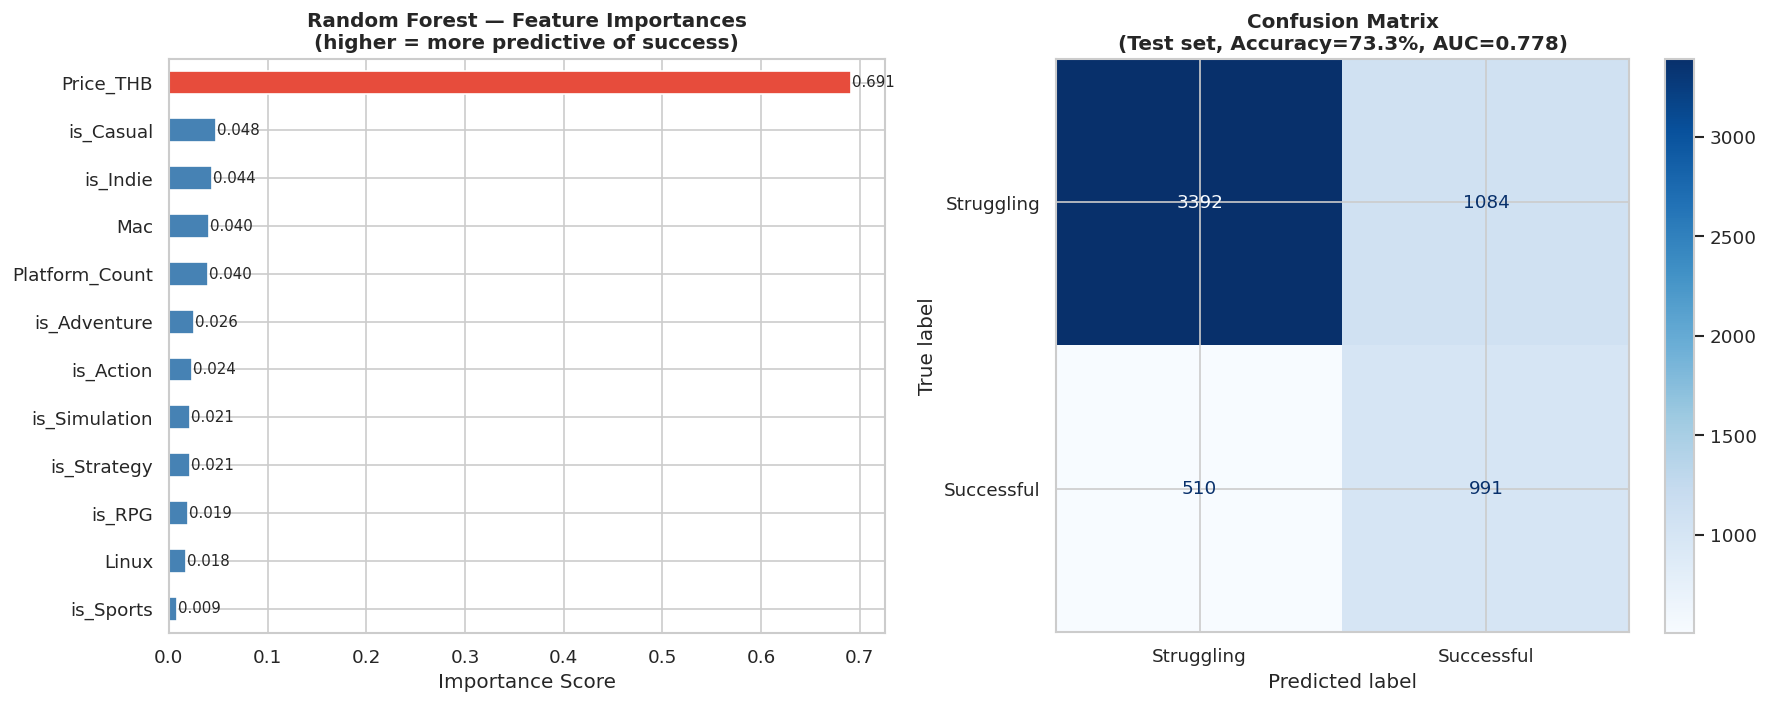

In [28]:
# ── Feature Importance Chart ──────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Horizontal bar chart
colors_imp = ['#e74c3c' if v == importances.max() else 'steelblue' for v in importances.values]
importances.plot.barh(ax=axes[0], color=colors_imp, edgecolor='white')
axes[0].set_title('Random Forest — Feature Importances\n(higher = more predictive of success)',
                   fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, val in enumerate(importances.values):
    axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=9)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Struggling', 'Successful'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title(f'Confusion Matrix\n(Test set, Accuracy={acc*100:.1f}%, AUC={roc:.3f})',
                   fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 12 — Top 10 Most Popular Games

                              Name Total_Reviews  Rating_Percent  Price_THB                                                  Genres
1                 Counter-Strike 2     5,017,291           85.50       0.00                                    Action, Free To Play
2              PUBG: BATTLEGROUNDS     1,757,970           55.80       0.00  Action, Adventure, Massively Multiplayer, Free To Play
3   Tom Clancy's Rainbow Six Siege     1,236,280           83.02       0.00                                    Action, Free To Play
4                         Terraria     1,205,722           97.56   11000.00                           Action, Adventure, Indie, RPG
5                             Rust     1,122,855           87.39     799.00    Action, Adventure, Indie, Massively Multiplayer, RPG
6                      Garry's Mod     1,058,906           96.96     219.00                               Casual, Indie, Simulation
7                   Stardew Valley       853,484           98.51     315.00 

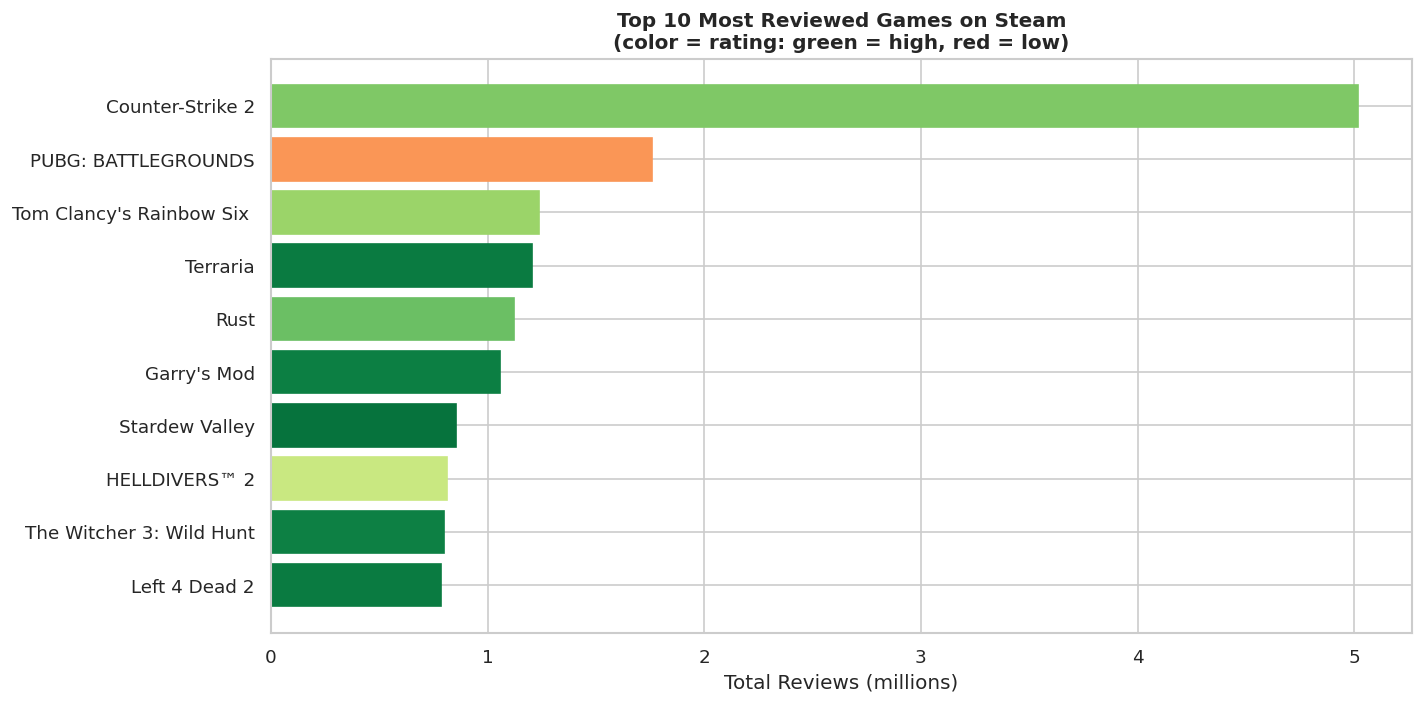

In [30]:
top10 = (
    df_clean
    .nlargest(10, 'Total_Reviews')
    [['Name', 'Total_Reviews', 'Rating_Percent', 'Price_THB', 'Genres']]
    .reset_index(drop=True)
)
top10.index += 1
top10['Total_Reviews'] = top10['Total_Reviews'].apply(lambda x: f'{x:,.0f}')
print(top10.to_string())

top10_plot = df_clean.nlargest(10, 'Total_Reviews').copy()
top10_plot['Name_Short'] = top10_plot['Name'].str[:25]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10_plot['Name_Short'][::-1], top10_plot['Total_Reviews'][::-1] / 1e6,
               color='steelblue', edgecolor='white')

cmap = plt.cm.RdYlGn
norm = plt.Normalize(40, 100)
for bar, rating in zip(bars, top10_plot['Rating_Percent'][::-1].values):
    bar.set_color(cmap(norm(rating)))

ax.set_title('Top 10 Most Reviewed Games on Steam\n(color = rating: green = high, red = low)',
             fontweight='bold')
ax.set_xlabel('Total Reviews (millions)')
plt.tight_layout()
plt.show()

---
## Step 13 — Final Summary: What Drives Success on Steam?

This table combines statistical evidence and ML feature importances.

In [33]:
imp_sorted = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print('=' * 68)
print('   STEAM ANALYSIS — KEY FINDINGS SUMMARY')
print('=' * 68)

free_avg = df_clean[df_clean['Price_THB'] == 0]['Rating_Percent'].mean()
paid_avg = df_clean[df_clean['Price_THB'] > 0]['Rating_Percent'].mean()

print(f"\n1. PRICE  (strongest factor)")
print(f"   Free games avg rating   : {free_avg:.1f}%")
print(f"   Paid games avg rating   : {paid_avg:.1f}%")
print(f"   Pearson r (price/rating): {r_price:.3f}")
print(f"   ANOVA F={F_stat:.1f}, p={p_anova:.2e}, η²={eta_sq:.3f}")
print(f"   RF Importance: {imp_sorted['Price_THB']:.3f}")

print(f"\n2. REVIEW COUNT  (weak factor)")
print(f"   Pearson r (log reviews / rating) : {r_pearson:.3f}")
print(f"   Spearman ρ                       : {r_spearman:.3f}")
print(f"   Partial r (controlling price)    : {r_partial:.3f}")
print(f"   → More reviews ≠ better game; effect mostly from price")

print(f"\n3. GENRE  (statistically significant, small effect)")
for row in genre_stats:
    imp_key = f"is_{row['Genre']}"
    cohens_d_val = row["Cohen's d"]
    print(f"   {row['Genre']:12s}: Pb-r={row['Pb-r']:+.3f}, d={cohens_d_val:+.3f}, RF imp={imp_sorted.get(imp_key,0):.3f}")

print(f"\n4. PLATFORM  (small positive effect)")
print(f"   ANOVA F={F_plat:.2f}, p={p_plat:.4f}")
print(f"   Mac RF imp={imp_sorted['Mac']:.3f}  Linux RF imp={imp_sorted['Linux']:.3f}")

print(f"\n5. ML MODEL PERFORMANCE")
print(f"   Algorithm        : Random Forest (200 trees, balanced classes)")
print(f"   Test Accuracy    : {acc*100:.1f}%")
print(f"   ROC-AUC (test)   : {roc:.3f}")
print(f"   ROC-AUC (5-fold) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"   Top feature      : {imp_sorted.index[0]} ({imp_sorted.iloc[0]:.3f})")
print('=' * 68)

   STEAM ANALYSIS — KEY FINDINGS SUMMARY

1. PRICE  (strongest factor)
   Free games avg rating   : 28.7%
   Paid games avg rating   : 69.3%
   Pearson r (price/rating): 0.119
   ANOVA F=2165.6, p=0.00e+00, η²=0.225
   RF Importance: 0.691

2. REVIEW COUNT  (weak factor)
   Pearson r (log reviews / rating) : 0.284
   Spearman ρ                       : 0.179
   Partial r (controlling price)    : 0.280
   → More reviews ≠ better game; effect mostly from price

3. GENRE  (statistically significant, small effect)
   Indie       : Pb-r=-0.006, d=-0.013, RF imp=0.044
   Action      : Pb-r=-0.025, d=-0.050, RF imp=0.024
   RPG         : Pb-r=-0.024, d=-0.064, RF imp=0.019
   Strategy    : Pb-r=-0.027, d=-0.067, RF imp=0.021
   Casual      : Pb-r=+0.003, d=+0.005, RF imp=0.048
   Adventure   : Pb-r=+0.015, d=+0.030, RF imp=0.026
   Simulation  : Pb-r=-0.064, d=-0.162, RF imp=0.021
   Sports      : Pb-r=-0.033, d=-0.154, RF imp=0.009

4. PLATFORM  (small positive effect)
   ANOVA F=207.51, p=0.

---
## Step 14 — Save Cleaned Dataset

In [34]:
output_path = 'steam_cleaned_analysis.csv'
df_clean.to_csv(output_path, index=False)
print(f'Saved {len(df_clean):,} rows to "{output_path}"')

Saved 29,885 rows to "steam_cleaned_analysis.csv"
